# Term Project 1: KNN Classification (CIFAR-10)

In [ ]:
# Import Libraries
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

# Load CIFAR-10
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

x_train = torch.stack([img for img, _ in train_dataset])
y_train = torch.tensor([label for _, label in train_dataset])
x_test = torch.stack([img for img, _ in test_dataset])
y_test = torch.tensor([label for _, label in test_dataset])

# Dataset Info
print("=== CIFAR-10 Dataset Information ===")
print(f"Training data: {list(x_train.shape)}")
print(f"Test data: {list(x_test.shape)}")

# Flatten + Normalize
x_train = x_train.view(x_train.size(0), -1).numpy()
x_test = x_test.view(x_test.size(0), -1).numpy()
y_train = y_train.numpy()
y_test = y_test.numpy()

print(f"\nFlattened image vector length: {x_train.shape[1]}")

# Standardization
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train.astype(np.float32)) #fit은 train에서만 (test data 누설 방지)
x_test = scaler.transform(x_test.astype(np.float32))

# Sample subset for Speed
x_train, _, y_train, _ = train_test_split(
    x_train, y_train, train_size=8000, stratify=y_train, random_state=42
)
x_test, _, y_test, _ = train_test_split(
    x_test, y_test, train_size=2000, stratify=y_test, random_state=42
)

print(f"\nTrain set: {len(x_train)}, Test set: {len(x_test)}")

# Reporting Metrics
def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro'),
        "Recall": recall_score(y_true, y_pred, average='macro'),
        "F1": f1_score(y_true, y_pred, average='macro')
    }


=== CIFAR-10 Dataset Information ===
Training data: [50000, 3, 32, 32]
Test data: [10000, 3, 32, 32]

Flattened image vector length: 3072

Train set: 8000, Test set: 2000


## 1. Simple KNN Classification - Train/Test Split

In [ ]:
k = 5
metric = 'euclidean'  # or 'manhattan'

print(f"=== [Train/Test] (k=5, metric={metric}) ===")
knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)

metrics_simple = compute_metrics(y_test, y_pred)
for k, v in metrics_simple.items():
    print(f"{k}: {v:.4f}")


=== [Train/Test] (k=5, metric=euclidean) ===
Accuracy: 0.2765
Precision: 0.3634
Recall: 0.2765
F1: 0.2525


## 2. KNN Classification - Train/Validation/Test Split

In [ ]:
k_values = [1, 3, 5, 7, 9]
metric_list = ['euclidean', 'manhattan']

x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

best_result = {"metric": None, "k": None, "val_acc": 0}

print("=== [Train/Validation/Test] Find Best (k, metric) ===")
for metric in metric_list:
    print(f"\n--- Metric: {metric} ---")
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(x_tr, y_tr)
        y_val_pred = knn.predict(x_val)
        acc = accuracy_score(y_val, y_val_pred)
        print(f"k={k}, Validation Accuracy={acc:.4f}")
        if acc > best_result["val_acc"]:
            best_result = {"metric": metric, "k": k, "val_acc": acc}

print("\n=== Best Validation Result ===")
print(f"Best Metric: {best_result['metric']}")
print(f"Best k: {best_result['k']}")
print(f"Validation Accuracy: {best_result['val_acc']:.4f}")

# Retrain with best (k, metric)
best_metric = best_result["metric"]
best_k = best_result["k"]
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_best.fit(np.concatenate((x_tr, x_val)), np.concatenate((y_tr, y_val))) # train+val 합쳐 재학습
y_pred_best = knn_best.predict(x_test) # test로 평가

metrics_val = compute_metrics(y_test, y_pred_best)
print("\n=== Test Performance with Best (k, metric) ===")
for key, value in metrics_val.items():
    print(f"{key}: {value:.4f}")


=== [Train/Validation/Test] Find Best (k, metric) ===

--- Metric: euclidean ---
k=1, Validation Accuracy=0.2863
k=3, Validation Accuracy=0.2888
k=5, Validation Accuracy=0.2981
k=7, Validation Accuracy=0.2812
k=9, Validation Accuracy=0.2888

--- Metric: manhattan ---
k=1, Validation Accuracy=0.3219
k=3, Validation Accuracy=0.2975
k=5, Validation Accuracy=0.3125
k=7, Validation Accuracy=0.3025
k=9, Validation Accuracy=0.3044

=== Best Validation Result ===
Best Metric: manhattan
Best k: 1
Validation Accuracy: 0.3219

=== Test Performance with Best (k, metric) ===
Accuracy: 0.3025
Precision: 0.3365
Recall: 0.3025
F1: 0.2963


## 3. KNN Classification - 5-Fold Cross Validation


=== [5-Fold Cross Validation] using best metric: manhattan ===

k=1:
  Accuracy: 0.3100 ± 0.0111
  Precision: 0.3514 ± 0.0146
  Recall: 0.3104 ± 0.0107
  F1: 0.3038 ± 0.0106

k=3:
  Accuracy: 0.3041 ± 0.0069
  Precision: 0.3799 ± 0.0106
  Recall: 0.3046 ± 0.0075
  F1: 0.2909 ± 0.0063

k=5:
  Accuracy: 0.3180 ± 0.0056
  Precision: 0.3808 ± 0.0140
  Recall: 0.3184 ± 0.0055
  F1: 0.3032 ± 0.0073

k=7:
  Accuracy: 0.3139 ± 0.0051
  Precision: 0.3824 ± 0.0095
  Recall: 0.3144 ± 0.0058
  F1: 0.2988 ± 0.0060

k=9:
  Accuracy: 0.3179 ± 0.0070
  Precision: 0.3914 ± 0.0068
  Recall: 0.3183 ± 0.0078
  F1: 0.3018 ± 0.0071


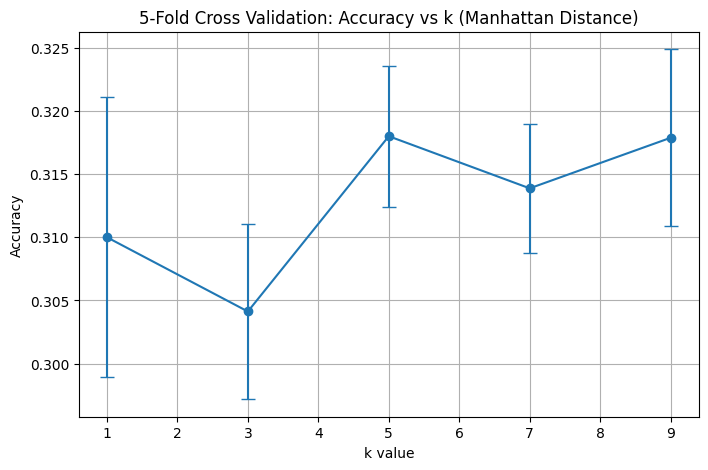

In [ ]:
print(f"\n=== [5-Fold Cross Validation] using best metric: {best_metric} ===")

k_values = [1, 3, 5, 7, 9]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store mean/std of all metrics
fold_results = {}

for k in k_values:
    fold_metrics = {"Accuracy": [], "Precision": [], "Recall": [], "F1": []}

    for train_idx, val_idx in kf.split(x_train):
        X_tr, X_val = x_train[train_idx], x_train[val_idx]
        Y_tr, Y_val = y_train[train_idx], y_train[val_idx]

        knn = KNeighborsClassifier(n_neighbors=k, metric=best_metric)
        knn.fit(X_tr, Y_tr)
        Y_val_pred = knn.predict(X_val)

        metrics = compute_metrics(Y_val, Y_val_pred)
        for key in fold_metrics:
            fold_metrics[key].append(metrics[key])

    # Calculate mean/std
    fold_results[k] = {m: (np.mean(vals), np.std(vals)) for m, vals in fold_metrics.items()}
    print(f"\nk={k}:")
    for m, (mean, std) in fold_results[k].items():
        print(f"  {m}: {mean:.4f} ± {std:.4f}")

# Plot Accuracy vs k
plt.figure(figsize=(8,5))
mean_acc = [fold_results[k]["Accuracy"][0] for k in k_values]
std_acc = [fold_results[k]["Accuracy"][1] for k in k_values]
plt.errorbar(k_values, mean_acc, yerr=std_acc, fmt='-o', capsize=5)
plt.title(f"5-Fold Cross Validation: Accuracy vs k ({best_metric.capitalize()} Distance)")
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()
